In [2]:
from pathlib import Path
import os

from PIL import Image
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import torch

#### SET THE CACHE DIR FOR HF MODEL

In [3]:
# this is done to update the folder where the models are downloaded
HF_CACHE_DIR = Path("../.hf_cache")
os.environ["HF_HOME"] = str(HF_CACHE_DIR.resolve())

#### LOAD THE MODEL & PRE-PROCESSOR

In [4]:
MODEL_PATH = "PaddlePaddle/PP-DocLayout_plus-L_safetensors"
model = AutoModelForObjectDetection.from_pretrained(MODEL_PATH)
image_processor = AutoImageProcessor.from_pretrained(MODEL_PATH)

model.eval()
type(model).__name__, type(image_processor).__name__

Loading weights:   0%|          | 0/889 [00:00<?, ?it/s]

('RTDetrForObjectDetection', 'RTDetrImageProcessor')

#### LOAD THE DOCUMENT IMAGE

In [5]:
IMAGE_PATH = "invesco-factsheet-april-2025-5.png"
image = Image.open(IMAGE_PATH)

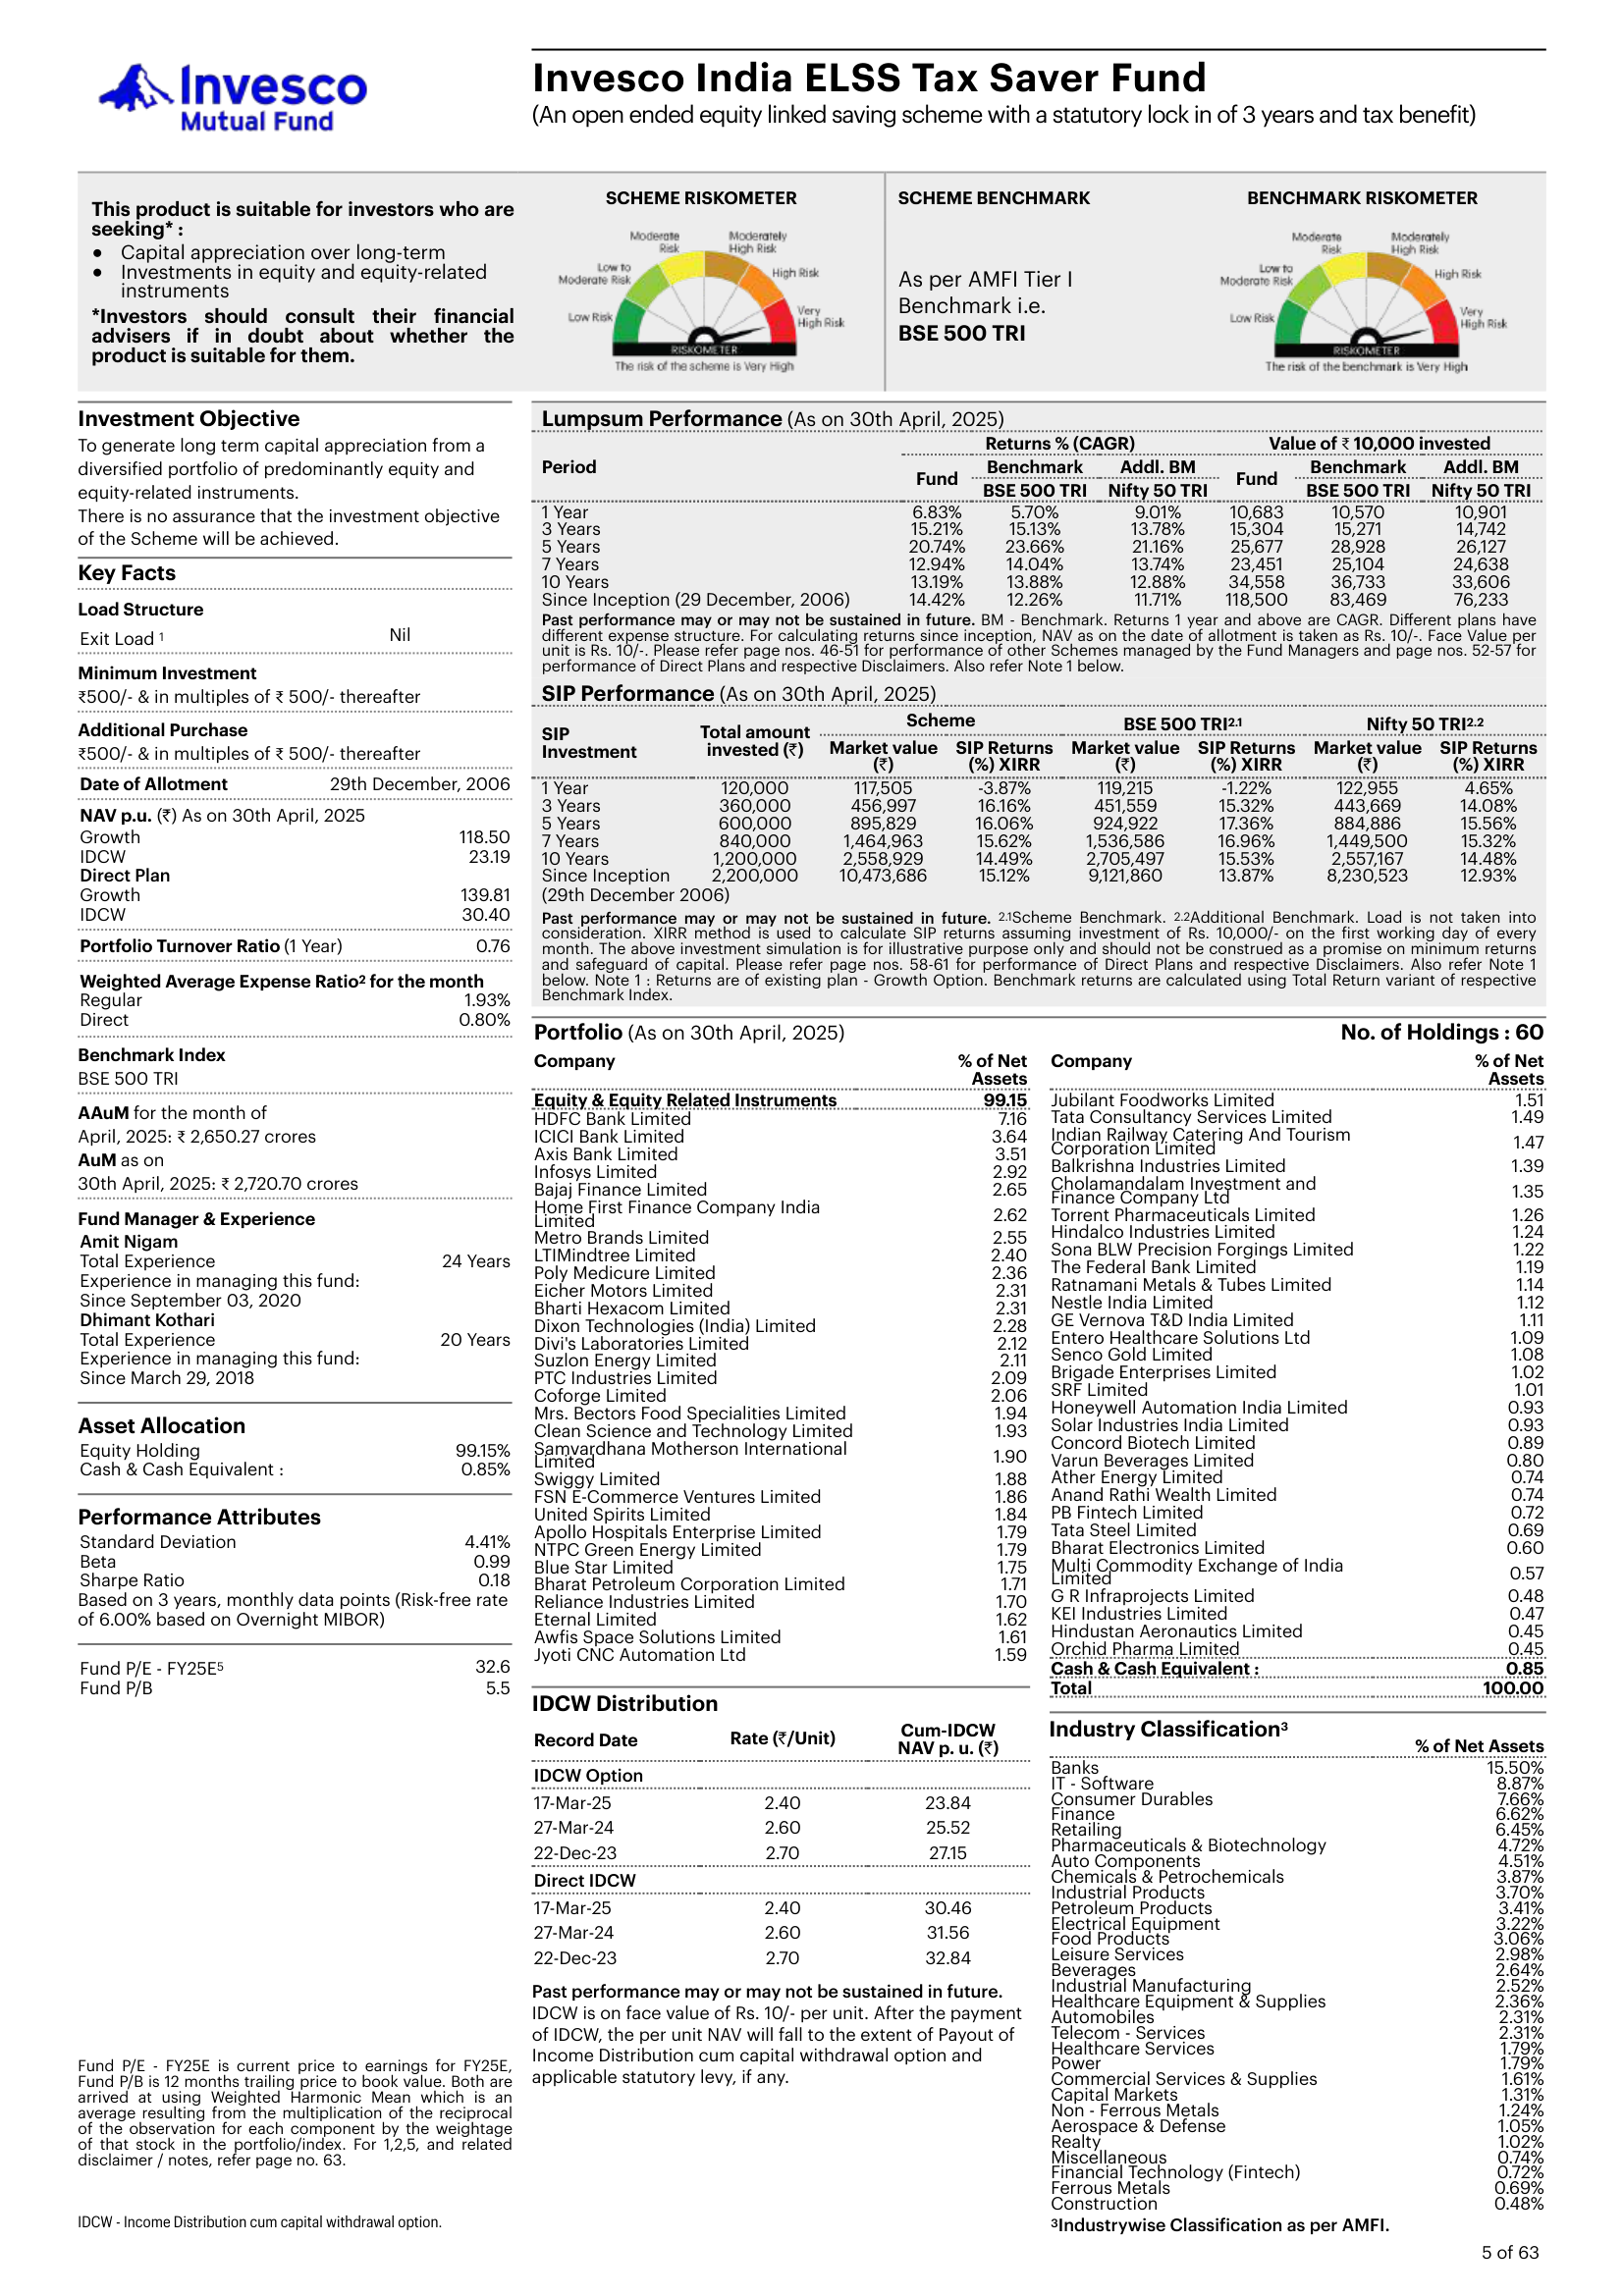

In [6]:
image

#### PRE-PROCESS THE DOCUMENT IMAGE

In [7]:
inputs = image_processor(images=image,return_tensors='pt')

#### RUN THE MODEL ON THE INPUT

In [8]:
with torch.no_grad():
    outputs = model(**inputs)

In [13]:
len(outputs),outputs[-1].shape, outputs[-2].shape

(12, torch.Size([1, 13125, 4]), torch.Size([1, 13125, 20]))

#### POST-PROCESS THE OUTPUT

In [ ]:
width, height = image.size
results = image_processor.post_process_object_detection(
    outputs,
    target_sizes = [(height, width)]
)

#### CHECK THE RAW RESULTS

In [ ]:
for result in results:
    for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
        score, label = score.item(), label_id.item()
        box = [round(i, 2) for i in box.tolist()]
        print(f"{model.config.id2label[label]}: {score:.2f} {box}")

#### DECODE THE RAW RESULTS

In [ ]:
# "image_processor_type": "RTDetrImageProcessor",
help(image_processor.post_process_object_detection)

[xmin, ymin, xmax, ymax]: These are the Bounding Box coordinates in absolute pixels (because target_sizes are used).

- x values: Distance from the left edge of the page.
- y values: Distance from the top edge of the page.

#### CONVERT THE RAW RESULTS REGIONS

In [ ]:
raw_regions = []
for result in results:
    for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
        score_value = score.item()
        label_id_value = label_id.item()
        box_value = [round(i, 2) for i in box.tolist()]
        raw_regions.append(
            {
                "label": model.config.id2label[label_id_value],
                "label_id": label_id_value,
                "score": score_value,
                "box": box_value,
            }
        )

raw_regions[0]

In [ ]:
# Filter and sort detected regions

def filter_and_sort_regions(regions, min_score=0.6):
    filtered = [region for region in regions if float(region["score"]) >= min_score]
    filtered.sort(key=lambda region: (region["box"][1], region["box"][0]))
    return filtered


filtered_regions = filter_and_sort_regions(raw_regions, min_score=0.2)
filtered_regions[0]

#### CROP EACH DETECTED REGION INTO ITS OWN SNAPSHOT

In [ ]:
i = 4
label = filtered_regions[i]['label']
box = filtered_regions[i]['box']
image.crop(box)

#### CREATE A WHITE CANVA

In [ ]:
# create white canvas
canvas = Image.new("RGB", image.size, (255, 255, 255))

for r in filtered_regions:
    x1, y1, x2, y2 = map(int, r["box"])

    # crop region
    crop = image.crop((x1, y1, x2, y2))

    # paste at same location
    canvas.paste(crop, (x1, y1))

canvas